In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [40]:
df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/healthcare_dataset (1).csv")
df

,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
0,Bobby JacksOn,30,Male,B-,Cancer,2024-01-31,Matthew Smith,Sons and Miller,Blue Cross,18856.281306,328,Urgent,2024-02-02,Paracetamol,Normal
1,LesLie TErRy,62,Male,A+,Obesity,2019-08-20,Samantha Davies,Kim Inc,Medicare,33643.327287,265,Emergency,2019-08-26,Ibuprofen,Inconclusive
2,DaNnY sMitH,76,Female,A-,Obesity,2022-09-22,Tiffany Mitchell,Cook PLC,Aetna,27955.096079,205,Emergency,2022-10-07,Aspirin,Normal
3,andrEw waTtS,28,Female,O+,Diabetes,2020-11-18,Kevin Wells,"Hernandez Rogers and Vang,",Medicare,37909.782410,450,Elective,2020-12-18,Ibuprofen,Abnormal
4,adrIENNE bEll,43,Female,AB+,Cancer,2022-09-19,Kathleen Hanna,White-White,Aetna,14238.317814,458,Urgent,2022-10-09,Penicillin,Abnormal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
55495,eLIZABeTH jaCkSOn,42,Female,O+,Asthma,2020-08-16,Joshua Jarvis,Jones-Thompson,Blue Cross,2650.714952,417,Elective,2020-09-15,Penicillin,Abnormal
55496,KYle pEREz,61,Female,AB-,Obesity,2020-01-23,Taylor Sullivan,Tucker-Moyer,Cigna,31457.797307,316,Elective,2020-02-01,Aspirin,Normal
55497,HEATher WaNG,38,Female,B+,Hypertension,2020-07-13,Joe Jacobs DVM,"and Mahoney Johnson Vasquez,",UnitedHealthcare,27620.764717,347,Urgent,2020-08-10,Ibuprofen,Abnormal
55498,JENniFER JOneS,43,Male,O-,Arthritis,2019-05-25,Kimberly Curry,"Jackson Todd and Castro,",Medicare,32451.092358,321,Elective,2019-05-31,Ibuprofen,Abnormal


In [41]:
df.head()

,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
0,Bobby JacksOn,30,Male,B-,Cancer,2024-01-31,Matthew Smith,Sons and Miller,Blue Cross,18856.281306,328,Urgent,2024-02-02,Paracetamol,Normal
1,LesLie TErRy,62,Male,A+,Obesity,2019-08-20,Samantha Davies,Kim Inc,Medicare,33643.327287,265,Emergency,2019-08-26,Ibuprofen,Inconclusive
2,DaNnY sMitH,76,Female,A-,Obesity,2022-09-22,Tiffany Mitchell,Cook PLC,Aetna,27955.096079,205,Emergency,2022-10-07,Aspirin,Normal
3,andrEw waTtS,28,Female,O+,Diabetes,2020-11-18,Kevin Wells,"Hernandez Rogers and Vang,",Medicare,37909.782410,450,Elective,2020-12-18,Ibuprofen,Abnormal
4,adrIENNE bEll,43,Female,AB+,Cancer,2022-09-19,Kathleen Hanna,White-White,Aetna,14238.317814,458,Urgent,2022-10-09,Penicillin,Abnormal


In [42]:
df.shape

(55500, 15)

In [43]:
df.describe()

,Age,Billing Amount,Room Number
count,55500.000000,55500.000000,55500.000000
mean,51.539459,25539.316097,301.134829
std,19.602454,14211.454431,115.243069
min,13.000000,-2008.492140,101.000000
25%,35.000000,13241.224652,202.000000
50%,52.000000,25538.069376,302.000000
75%,68.000000,37820.508436,401.000000
max,89.000000,52764.276736,500.000000


In [44]:
print(df.isnull().sum())

Name                  0
Age                   0
Gender                0
Blood Type            0
Medical Condition     0
Date of Admission     0
Doctor                0
Hospital              0
Insurance Provider    0
Billing Amount        0
Room Number           0
Admission Type        0
Discharge Date        0
Medication            0
Test Results          0
dtype: int64


In [45]:
df = df.dropna()

In [46]:
df["Date of Admission"] = pd.to_datetime(df["Date of Admission"], utc=True)
df['Date of Admission'].dtype

datetime64[ns, UTC]

In [47]:
df["Discharge Date"] = pd.to_datetime(df["Discharge Date"], utc=True)
df['Discharge Date'].dtype

datetime64[ns, UTC]

In [48]:
df["Hospital_Stays"] = df["Discharge Date"] - df["Date of Admission"]
df['Hospital_Stays'] = df['Hospital_Stays'].dt.days
df

,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results,Hospital_Stays
0,Bobby JacksOn,30,Male,B-,Cancer,2024-01-31 00:00:00+00:00,Matthew Smith,Sons and Miller,Blue Cross,18856.281306,328,Urgent,2024-02-02 00:00:00+00:00,Paracetamol,Normal,2
1,LesLie TErRy,62,Male,A+,Obesity,2019-08-20 00:00:00+00:00,Samantha Davies,Kim Inc,Medicare,33643.327287,265,Emergency,2019-08-26 00:00:00+00:00,Ibuprofen,Inconclusive,6
2,DaNnY sMitH,76,Female,A-,Obesity,2022-09-22 00:00:00+00:00,Tiffany Mitchell,Cook PLC,Aetna,27955.096079,205,Emergency,2022-10-07 00:00:00+00:00,Aspirin,Normal,15
3,andrEw waTtS,28,Female,O+,Diabetes,2020-11-18 00:00:00+00:00,Kevin Wells,"Hernandez Rogers and Vang,",Medicare,37909.782410,450,Elective,2020-12-18 00:00:00+00:00,Ibuprofen,Abnormal,30
4,adrIENNE bEll,43,Female,AB+,Cancer,2022-09-19 00:00:00+00:00,Kathleen Hanna,White-White,Aetna,14238.317814,458,Urgent,2022-10-09 00:00:00+00:00,Penicillin,Abnormal,20
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
55495,eLIZABeTH jaCkSOn,42,Female,O+,Asthma,2020-08-16 00:00:00+00:00,Joshua Jarvis,Jones-Thompson,Blue Cross,2650.714952,417,Elective,2020-09-15 00:00:00+00:00,Penicillin,Abnormal,30
55496,KYle pEREz,61,Female,AB-,Obesity,2020-01-23 00:00:00+00:00,Taylor Sullivan,Tucker-Moyer,Cigna,31457.797307,316,Elective,2020-02-01 00:00:00+00:00,Aspirin,Normal,9
55497,HEATher WaNG,38,Female,B+,Hypertension,2020-07-13 00:00:00+00:00,Joe Jacobs DVM,"and Mahoney Johnson Vasquez,",UnitedHealthcare,27620.764717,347,Urgent,2020-08-10 00:00:00+00:00,Ibuprofen,Abnormal,28
55498,JENniFER JOneS,43,Male,O-,Arthritis,2019-05-25 00:00:00+00:00,Kimberly Curry,"Jackson Todd and Castro,",Medicare,32451.092358,321,Elective,2019-05-31 00:00:00+00:00,Ibuprofen,Abnormal,6


In [49]:
billing = df.groupby(["Medical Condition", "Insurance Provider"])["Billing Amount"].sum().unstack()
billing

Insurance Provider,Aetna,Blue Cross,Cigna,Medicare,UnitedHealthcare
Medical Condition,,,,,
Arthritis,4.667744e+07,4.776824e+07,4.810453e+07,4.677861e+07,4.800029e+07
Asthma,4.497371e+07,4.613516e+07,4.883917e+07,4.722901e+07,4.828272e+07
Cancer,4.533568e+07,4.538242e+07,4.768493e+07,4.728065e+07,4.648417e+07
Diabetes,4.709108e+07,4.802529e+07,4.855774e+07,4.885277e+07,4.601285e+07
Hypertension,4.858130e+07,4.658659e+07,4.527089e+07,4.767472e+07,4.760715e+07
Obesity,4.620389e+07,4.935658e+07,4.868209e+07,4.790500e+07,4.606736e+07


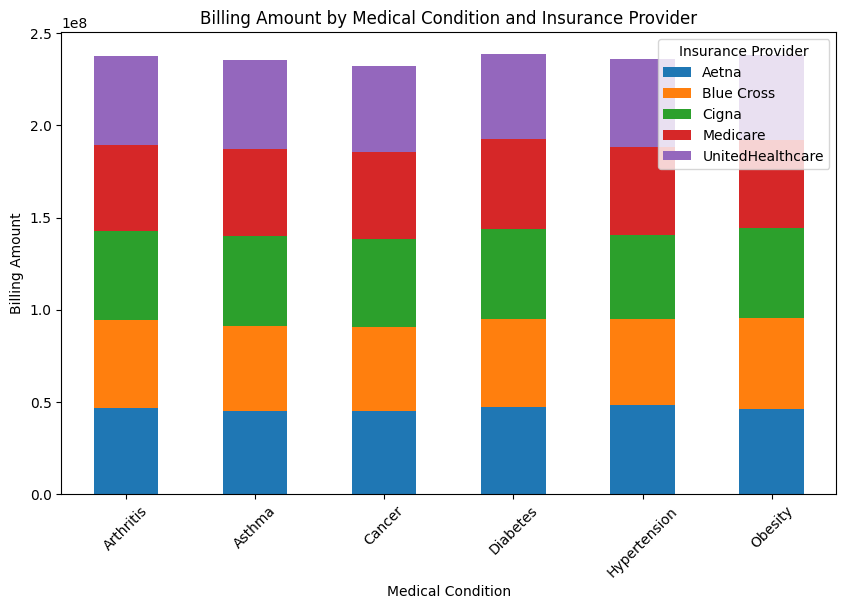

In [50]:
billing.plot(
    kind="bar",
    stacked=True,
    figsize=(10, 6)
)
plt.xlabel("Medical Condition")
plt.ylabel("Billing Amount")
plt.title("Billing Amount by Medical Condition and Insurance Provider")
plt.xticks(rotation=45)
plt.legend(title="Insurance Provider")
plt.show()

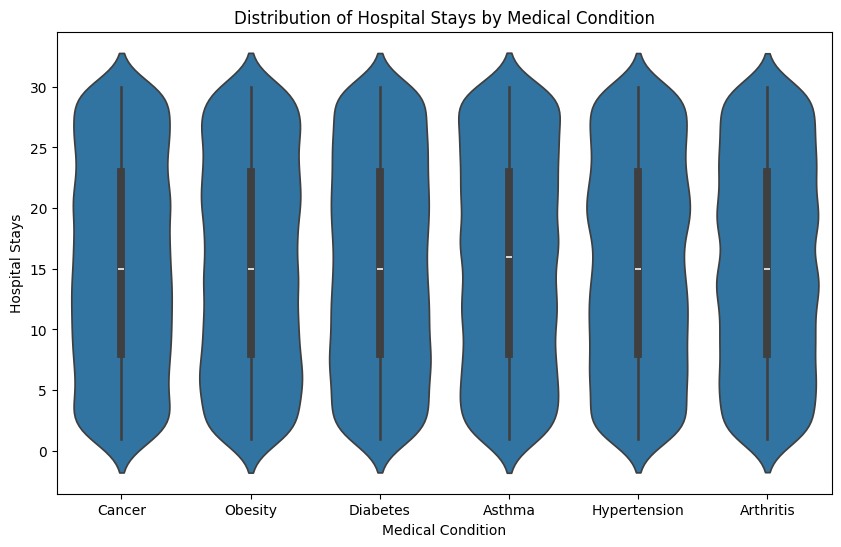

In [51]:
plt.figure(figsize=(10, 6))
sns.violinplot(
    x="Medical Condition",
    y="Hospital_Stays",
    data=df,
)
plt.title("Distribution of Hospital Stays by Medical Condition")
plt.xlabel("Medical Condition")
plt.ylabel("Hospital Stays")
plt.show()